# 🏠 House Price Prediction Using Machine Learning

## An Explainable AI Approach for Smart Real Estate Valuation

### XYlofy AI Data Science Internship Project

---

##  Project Introduction

## Business Problem

Real estate buyers, sellers, and businesses often face challenges in estimating the fair market value of properties. Traditional valuation methods mainly depend on manual comparisons and subjective assumptions, which may lead to inaccurate pricing decisions.

Property prices are influenced by multiple factors such as area, number of bedrooms, bathrooms, facilities, and location-related characteristics.

This project aims to develop an explainable machine learning-based house price prediction system that not only estimates property prices but also identifies the key factors contributing to real estate valuation.
---

## Objective

The main objectives of this project are:

- To analyze real estate data and understand pricing patterns.
- To clean and prepare the dataset for machine learning.
- To build regression models for predicting house prices.
- To compare model performance using evaluation metrics.
- To identify the most important features affecting house prices.
- To generate business insights for real estate decision-making.

---

## Machine Learning Approach

This project follows a complete and structured Data Science workflow that transforms raw housing data into meaningful predictions and actionable insights.

The workflow includes:
1. Data Collection
2. Data Exploration
3. Data Cleaning
4. Feature Engineering
5. Model Development
6. Model Evaluation
7. Visualization
8. Business Insights

---

## Tools and Technologies Used

| Tool | Purpose |
|------|---------|
| Python | Programming Language |
| Jupyter Notebook | Development Environment |
| Pandas | Data Loading and Processing |
| NumPy | Numerical Operations |
| Matplotlib | Data Visualization |
| Seaborn | Statistical Visualization |
| Scikit-learn | Machine Learning Models |


In [3]:
# Importing Required Libraries

import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning libraries
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Evaluation metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("All libraries imported successfully!")

All libraries imported successfully!


# 1. Data Loading and Exploration

## Dataset Overview

The dataset used in this project is the Housing Prices Dataset.

The objective is to analyze property-related features and build a machine learning model that can predict house prices accurately.

The dataset contains information about various properties including area, number of bedrooms, bathrooms, furnishing status, and other facilities.

### Target Variable

**Price** The final house price that the model will predict.

### Feature Variables

All other columns represent property characteristics that help the model understand price patterns.

In [7]:
# Loading the Housing Dataset

df = pd.read_csv("Housing.csv")

print("Dataset loaded successfully!")

df.head(10)

Dataset loaded successfully!


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


## Dataset Dimensions

Before performing analysis, it is important to understand the size of the dataset.

The dataset dimensions represent:
- Number of rows → Number of house records
- Number of columns → Number of available features

In [8]:
# Checking the number of rows and columns

df.shape

(545, 13)

In [9]:
# Displaying all column names

df.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='str')

## Dataset Information

The dataset information helps us understand:
- Feature names
- Data types
- Number of non-null values
- Presence of missing data

In [10]:
# Checking dataset information

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    str  
 6   guestroom         545 non-null    str  
 7   basement          545 non-null    str  
 8   hotwaterheating   545 non-null    str  
 9   airconditioning   545 non-null    str  
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    str  
 12  furnishingstatus  545 non-null    str  
dtypes: int64(6), str(7)
memory usage: 55.5 KB


## Statistical Summary

Statistical analysis helps us understand the distribution of numerical features.

It provides:
- Mean value
- Minimum value
- Maximum value
- Standard deviation
- Quartile information

In [11]:
# Generating statistical summary

df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


## Target Variable and Feature Identification

In machine learning, the target variable is the value that the model learns to predict.

For this project:

**Target Variable:**
- Price

The remaining columns are considered feature variables because they provide information that helps the model estimate house prices.

**Feature Variables:**
- Area
- Bedrooms
- Bathrooms
- Stories
- Mainroad
- Guestroom
- Basement
- Hot water heating
- Air conditioning
- Parking
- Prefurnished area
- Furnishing status

In [12]:
# Separating target variable and feature variables

target = "price"

features = df.drop(target, axis=1)

print("Target Variable:")
print(target)

print("\nFeature Variables:")
print(features.columns.tolist())

Target Variable:
price

Feature Variables:
['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']


## Missing Value Analysis

Missing values can affect machine learning performance.

Therefore, we check each feature for missing data before beginning data preparation.

In [13]:
# Checking missing values

missing_values = df.isnull().sum()

missing_values

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

## Initial Dataset Observations

From the initial exploration:

- The dataset contains 545 house records with 13 attributes.
- Price is identified as the prediction target.
- The dataset contains both numerical and categorical features.
- No missing values were found, indicating that the dataset is relatively clean.
- Categorical features need encoding before applying machine learning algorithms.
- Features such as area, number of rooms, and facilities may influence house prices.

# 2. Data Cleaning and Preparation

Data preprocessing is an important step before applying machine learning algorithms.

Raw datasets may contain duplicate records, categorical values, and inconsistent formats that cannot be directly used by ML models.

In this section, we transform the original dataset into a clean and machine-learning-ready format.

In [14]:
# Creating a copy of the original dataset

data = df.copy()

print("Dataset copy created successfully!")

Dataset copy created successfully!


## Duplicate Data Detection

Duplicate records represent repeated observations in the dataset.

We identify and remove duplicate rows to improve data quality.

In [15]:
# Checking duplicate rows

duplicates = data.duplicated().sum()

print("Number of duplicate rows:", duplicates)

Number of duplicate rows: 0


In [16]:
# Removing duplicate rows

data = data.drop_duplicates()

print("Duplicates removed successfully!")

Duplicates removed successfully!


## Handling Categorical Variables

Machine learning algorithms work with numerical data.

Therefore, categorical features containing text values are converted into numerical representation using encoding techniques.

For this dataset, One-Hot Encoding is used to transform categorical variables.

In [20]:
# Checking categorical columns

categorical_columns = data.select_dtypes(include='str').columns

categorical_columns

Index(['mainroad', 'guestroom', 'basement', 'hotwaterheating',
       'airconditioning', 'prefarea', 'furnishingstatus'],
      dtype='str')

## Encoding Categorical Variables

Machine learning algorithms require numerical input values to perform mathematical calculations.

However, the housing dataset contains categorical features with text values such as "yes", "no", and different furnishing categories.

To make these features understandable for machine learning models, categorical variables are converted into numerical form using One-Hot Encoding.

One-Hot Encoding creates separate binary columns representing different categories.

In [21]:
# Applying One-Hot Encoding to convert categorical features into numerical format

data_encoded = pd.get_dummies(data, drop_first=True)

print("Categorical variables encoded successfully!")

data_encoded.head()

Categorical variables encoded successfully!


,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,True,False,False,False,True,True,False,False
1,12250000,8960,4,4,4,3,True,False,False,False,True,False,False,False
2,12250000,9960,3,2,2,2,True,False,True,False,False,True,True,False
3,12215000,7500,4,2,2,3,True,False,True,False,True,True,False,False
4,11410000,7420,4,1,2,2,True,True,True,False,True,False,False,False


## Verification of Encoded Dataset

After encoding categorical variables, all features should be converted into numerical format because machine learning models cannot directly process text values.

In [23]:
# Checking dataset information after encoding

data_encoded.info()

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 14 columns):
 #   Column                           Non-Null Count  Dtype
---  ------                           --------------  -----
 0   price                            545 non-null    int64
 1   area                             545 non-null    int64
 2   bedrooms                         545 non-null    int64
 3   bathrooms                        545 non-null    int64
 4   stories                          545 non-null    int64
 5   parking                          545 non-null    int64
 6   mainroad_yes                     545 non-null    bool 
 7   guestroom_yes                    545 non-null    bool 
 8   basement_yes                     545 non-null    bool 
 9   hotwaterheating_yes              545 non-null    bool 
 10  airconditioning_yes              545 non-null    bool 
 11  prefarea_yes                     545 non-null    bool 
 12  furnishingstatus_semi-furnished  545 non-null    bool 
 13  f

### Converting Boolean Features into Numerical Format

Although one-hot encoding converts categorical variables into machine-readable form, boolean values are converted into integer format (0 and 1) to ensure compatibility with machine learning algorithms.

In [30]:
# Converting boolean columns into integer format

final_data = data_encoded.astype(int)

final_data.head()

,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,1,0,0,0,1,1,0,0
1,12250000,8960,4,4,4,3,1,0,0,0,1,0,0,0
2,12250000,9960,3,2,2,2,1,0,1,0,0,1,1,0
3,12215000,7500,4,2,2,3,1,0,1,0,1,1,0,0
4,11410000,7420,4,1,2,2,1,1,1,0,1,0,0,0


In [31]:
# Checking final dataset information

final_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 14 columns):
 #   Column                           Non-Null Count  Dtype
---  ------                           --------------  -----
 0   price                            545 non-null    int64
 1   area                             545 non-null    int64
 2   bedrooms                         545 non-null    int64
 3   bathrooms                        545 non-null    int64
 4   stories                          545 non-null    int64
 5   parking                          545 non-null    int64
 6   mainroad_yes                     545 non-null    int64
 7   guestroom_yes                    545 non-null    int64
 8   basement_yes                     545 non-null    int64
 9   hotwaterheating_yes              545 non-null    int64
 10  airconditioning_yes              545 non-null    int64
 11  prefarea_yes                     545 non-null    int64
 12  furnishingstatus_semi-furnished  545 non-null    int64
 13  f

## Final Dataset Structure

After preprocessing, the dataset is now ready for machine learning.

We check the final dimensions to understand how many features will be provided to the model.

In [25]:
# Checking final number of rows and columns

data_encoded.shape

(545, 14)

## Dataset Transformation Summary

The raw dataset contained both numerical and categorical information.

After preprocessing:
- Duplicate records were removed.
- Categorical variables were converted into numerical representations.
- The dataset became suitable for machine learning algorithms.

In [26]:
# Comparing original and processed dataset dimensions

print("Original Dataset Shape:", data.shape)
print("Processed Dataset Shape:", data_encoded.shape)

Original Dataset Shape: (545, 13)
Processed Dataset Shape: (545, 14)


# 3. Exploratory Data Analysis (EDA)

Exploratory Data Analysis helps us understand patterns, relationships, and important factors present in the housing dataset before building machine learning models.

In this section, we analyze how different property characteristics influence house prices through statistical analysis and visualization.

## 3.1 House Price Distribution

Understanding the distribution of house prices helps identify the pricing range and detect whether the dataset contains extreme values.

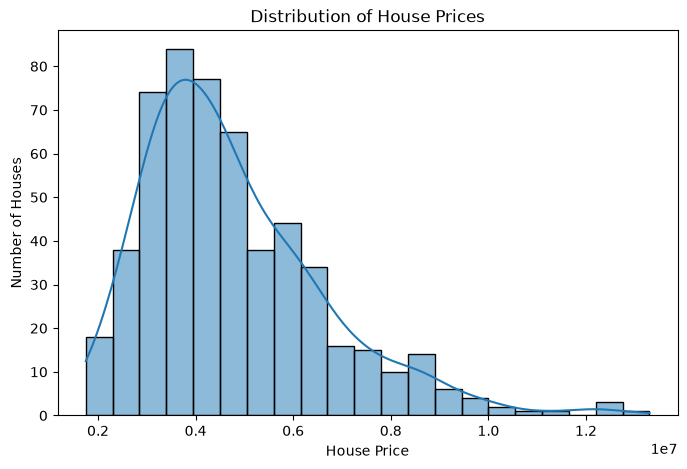

In [50]:
# Importing visualization libraries

import matplotlib.pyplot as plt
import seaborn as sns


# Plotting price distribution

plt.figure(figsize=(8,5))

sns.histplot(data_encoded['price'], kde=True)

plt.title("Distribution of House Prices")

plt.xlabel("House Price")

plt.ylabel("Number of Houses")

plt.savefig("charts/price_distribution.png", bbox_inches="tight")

plt.show()

Observation:

The price distribution shows that most houses are available within a moderate price range, while a smaller number of properties have significantly higher prices. The right-skewed distribution indicates that premium properties are less frequent but contribute to the higher end of the price range.

## 3.2 Relationship Between Area and House Price

Area is expected to be one of the major factors affecting property value. This analysis examines the relationship between property size and price.

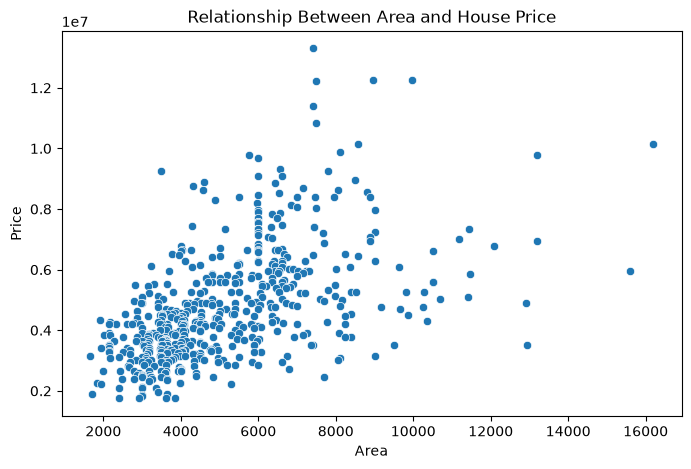

In [54]:
# Visualizing relationship between area and price

plt.figure(figsize=(8,5))

sns.scatterplot(
    data=data_encoded,
    x='area',
    y='price'
)

plt.title("Relationship Between Area and House Price")

plt.xlabel("Area")

plt.ylabel("Price")

plt.savefig("charts/area_vs_price.png", bbox_inches="tight")

plt.show()

Observation:

The scatter plot shows a positive relationship between house area and price. Generally, larger houses tend to have higher prices. However, the variation in prices for similar areas indicates that other features such as location, facilities, and property characteristics also influence house valuation.

## 3.3 Feature Correlation Analysis

Correlation analysis helps us understand the relationship between different property features and house prices.

It identifies which features have stronger positive or negative relationships with the target variable (Price).

This analysis helps in understanding important factors that may influence real estate valuation before building machine learning models.

In [32]:
# Generating correlation matrix for numerical analysis

correlation_matrix = final_data.corr()

correlation_matrix

,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
price,1.000000,0.535997,0.366494,0.517545,0.420712,0.384394,0.296898,0.255517,0.187057,0.093073,0.452954,0.329777,0.063656,-0.280587
area,0.535997,1.000000,0.151858,0.193820,0.083996,0.352980,0.288874,0.140297,0.047417,-0.009229,0.222393,0.234779,0.006156,-0.142278
bedrooms,0.366494,0.151858,1.000000,0.373930,0.408564,0.139270,-0.012033,0.080549,0.097312,0.046049,0.160603,0.079023,0.050040,-0.126252
bathrooms,0.517545,0.193820,0.373930,1.000000,0.326165,0.177496,0.042398,0.126469,0.102106,0.067159,0.186915,0.063472,0.029834,-0.132107
stories,0.420712,0.083996,0.408564,0.326165,1.000000,0.045547,0.121706,0.043538,-0.172394,0.018847,0.293602,0.044425,-0.003648,-0.082972
parking,0.384394,0.352980,0.139270,0.177496,0.045547,1.000000,0.204433,0.037466,0.051497,0.067864,0.159173,0.091627,0.041327,-0.165705
mainroad_yes,0.296898,0.288874,-0.012033,0.042398,0.121706,0.204433,1.000000,0.092337,0.044002,-0.011781,0.105423,0.199876,0.011450,-0.133123
guestroom_yes,0.255517,0.140297,0.080549,0.126469,0.043538,0.037466,0.092337,1.000000,0.372066,-0.010308,0.138179,0.160897,0.005821,-0.099023
basement_yes,0.187057,0.047417,0.097312,0.102106,-0.172394,0.051497,0.044002,0.372066,1.000000,0.004385,0.047341,0.228083,0.050284,-0.117935
hotwaterheating_yes,0.093073,-0.009229,0.046049,0.067159,0.018847,0.067864,-0.011781,-0.010308,0.004385,1.000000,-0.130023,-0.059411,0.063819,-0.059194


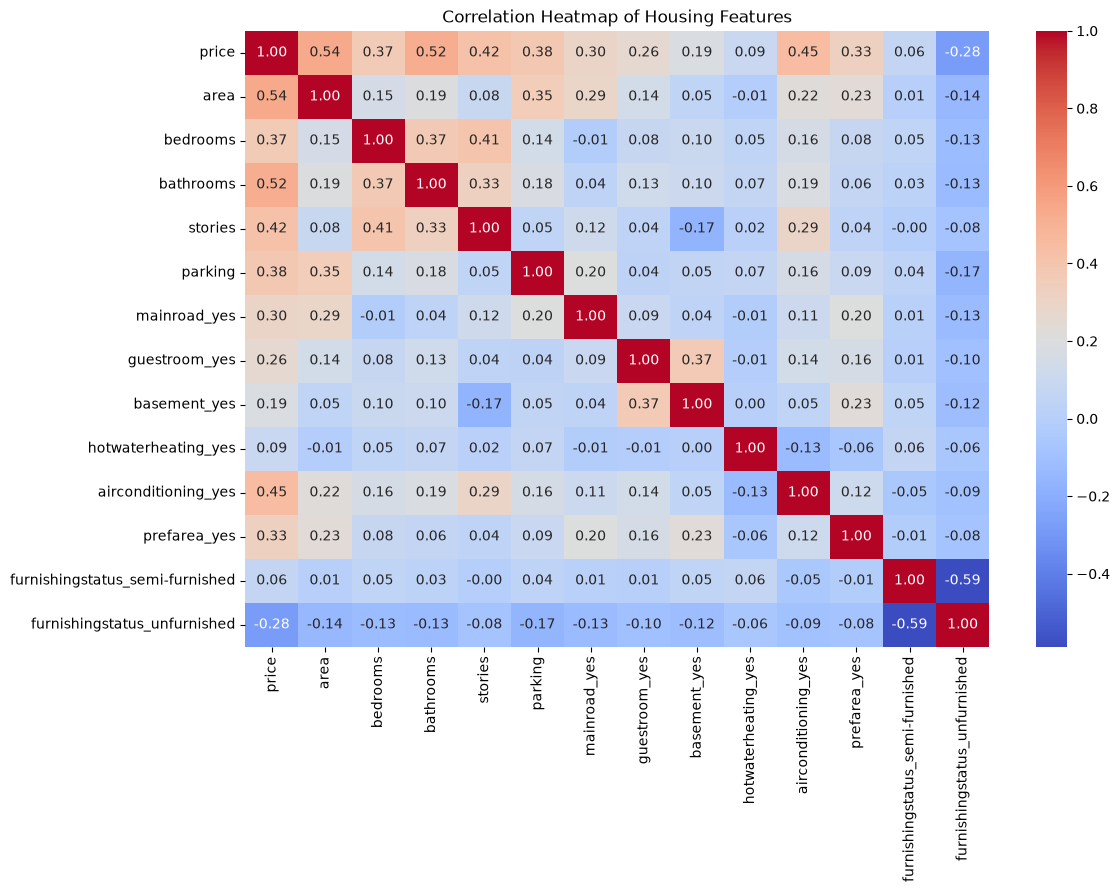

In [52]:
# Visualizing feature correlations using heatmap

plt.figure(figsize=(12,8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap of Housing Features")
plt.savefig("charts/correlation_heatmap.png", bbox_inches="tight")
plt.show()

In [34]:
# Identifying features most correlated with house price

price_correlation = correlation_matrix["price"].sort_values(ascending=False)

price_correlation

price                              1.000000
area                               0.535997
bathrooms                          0.517545
airconditioning_yes                0.452954
stories                            0.420712
parking                            0.384394
bedrooms                           0.366494
prefarea_yes                       0.329777
mainroad_yes                       0.296898
guestroom_yes                      0.255517
basement_yes                       0.187057
hotwaterheating_yes                0.093073
furnishingstatus_semi-furnished    0.063656
furnishingstatus_unfurnished      -0.280587
Name: price, dtype: float64

### Observation

The correlation analysis provides insights into which property features are associated with house prices.

Features with higher positive correlation values indicate stronger relationships with property valuation.

The analysis suggests that factors such as area, number of bathrooms, number of bedrooms, and additional facilities contribute significantly to determining house prices.

## 4. Feature Engineering and Model Preparation

Machine learning algorithms require input variables (features) and an output variable (target) separately.

In this step, the dataset is divided into:
- Features (X): Property characteristics used for prediction
- Target (y): House price that the model needs to predict

The prepared data is then split into training and testing sets to evaluate model performance on unseen data.

In [35]:
# Separating independent features and target variable

X = final_data.drop("price", axis=1)

y = final_data["price"]

print("Feature dataset shape:", X.shape)
print("Target dataset shape:", y.shape)

Feature dataset shape: (545, 13)
Target dataset shape: (545,)


### Train-Test Split

The dataset is divided into two parts:

Training Data:
Used by the model to learn patterns from existing data.

Testing Data:
Used to evaluate how well the model performs on new unseen data.

An 80-20 split ratio is used, where 80% data is used for training and 20% for testing.

In [36]:
# Splitting dataset into training and testing sets

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data size:", X_train.shape)
print("Testing data size:", X_test.shape)

Training data size: (436, 13)
Testing data size: (109, 13)


In [37]:
# Checking first few rows of training data

X_train.head()

,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
46,6000,3,2,4,1,1,0,0,0,1,0,0,0
93,7200,3,2,1,3,1,0,1,0,1,0,1,0
335,3816,2,1,1,2,1,0,1,0,1,0,0,0
412,2610,3,1,2,0,1,0,1,0,0,1,0,1
471,3750,3,1,2,0,1,0,0,0,0,0,0,1


# 5. Model Building

Machine learning models are trained to learn the relationship between property features and house prices.

In this project, regression algorithms are used because the target variable (house price) is a continuous numerical value.

Two models are implemented:

1. Linear Regression :
   A simple baseline regression algorithm that identifies linear relationships between features and house prices.

2. Random Forest Regressor:
   An ensemble learning algorithm that combines multiple decision trees to capture complex patterns and improve prediction accuracy.

The performance of both models will be compared using evaluation metrics.

In [39]:
# Importing Machine Learning Models and Evaluation Metrics

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import numpy as np

## 5.1 Linear Regression Model

Linear Regression is used as the baseline model.

It assumes that the relationship between input features and house prices can be represented using a linear equation.

This model helps establish a performance benchmark for comparing advanced algorithms.

In [40]:
# Creating Linear Regression model

linear_model = LinearRegression()


# Training the model using training data

linear_model.fit(X_train, y_train)


# Predicting house prices

linear_predictions = linear_model.predict(X_test)


print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


## 5.2 Random Forest Regression Model

Random Forest Regressor is an ensemble machine learning algorithm.

It creates multiple decision trees and combines their predictions to improve accuracy and handle complex relationships between property features and prices.

In [41]:
# Creating Random Forest model

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)


# Training the model

rf_model.fit(X_train, y_train)


# Predicting house prices

rf_predictions = rf_model.predict(X_test)


print("Random Forest model trained successfully!")

Random Forest model trained successfully!


# 6. Model Evaluation

Model evaluation helps determine how accurately the machine learning models predict house prices.

The following evaluation metrics are used:

### Mean Absolute Error (MAE)
Measures the average difference between actual and predicted house prices.

### Root Mean Squared Error (RMSE)
Measures prediction error while giving higher importance to large mistakes.

### R² Score
Represents how much variation in house prices is explained by the model.

Higher R² values and lower error values indicate better model performance.

In [42]:
# Evaluating Linear Regression Model

linear_mae = mean_absolute_error(y_test, linear_predictions)

linear_rmse = np.sqrt(
    mean_squared_error(y_test, linear_predictions)
)

linear_r2 = r2_score(
    y_test,
    linear_predictions
)

print("Linear Regression Performance")
print("MAE:", linear_mae)
print("RMSE:", linear_rmse)
print("R2 Score:", linear_r2)

Linear Regression Performance
MAE: 970043.4039201637
RMSE: 1324506.9600914388
R2 Score: 0.6529242642153184


In [43]:
# Evaluating Random Forest Model

rf_mae = mean_absolute_error(
    y_test,
    rf_predictions
)

rf_rmse = np.sqrt(
    mean_squared_error(y_test, rf_predictions)
)

rf_r2 = r2_score(
    y_test,
    rf_predictions
)

print("Random Forest Performance")
print("MAE:", rf_mae)
print("RMSE:", rf_rmse)
print("R2 Score:", rf_r2)

Random Forest Performance
MAE: 1021546.0353211008
RMSE: 1400565.9728553821
R2 Score: 0.611918531405699


In [44]:
# Comparing Model Performance

comparison = pd.DataFrame({

    "Model": [
        "Linear Regression",
        "Random Forest"
    ],

    "MAE": [
        linear_mae,
        rf_mae
    ],

    "RMSE": [
        linear_rmse,
        rf_rmse
    ],

    "R2 Score": [
        linear_r2,
        rf_r2
    ]

})

comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,9.700434e+05,1.324507e+06,0.652924
1,Random Forest,1.021546e+06,1.400566e+06,0.611919


### Model Evaluation Insights

The performance comparison shows that Linear Regression outperformed Random Forest Regressor on this dataset.

Linear Regression achieved a lower Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE), indicating more accurate price predictions.

Additionally, Linear Regression obtained a higher R² Score, explaining approximately 65.3% of the variation in house prices.

Based on the evaluation results, Linear Regression is selected as the final prediction model for this project.

# 7. Visualization of Model Performance

Visualizing model predictions helps understand how closely the predicted house prices match the actual house prices.

A scatter plot is used to compare actual values with predicted values.

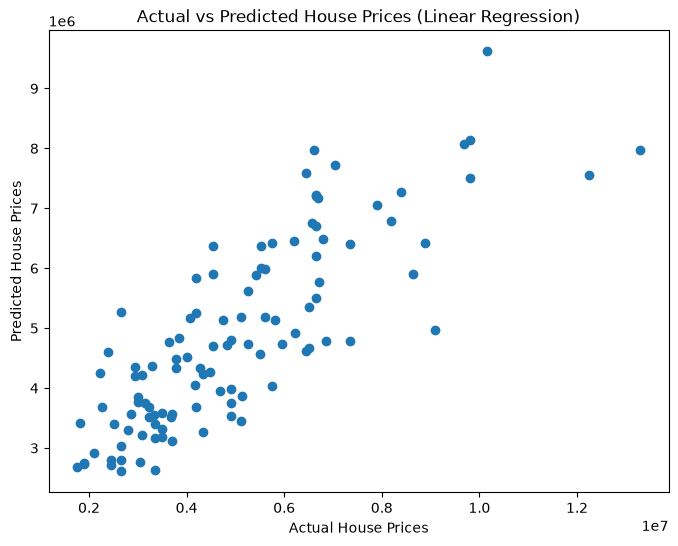

In [53]:
# Actual vs Predicted Price Visualization

plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    linear_predictions
)

plt.xlabel("Actual House Prices")
plt.ylabel("Predicted House Prices")

plt.title("Actual vs Predicted House Prices (Linear Regression)")

plt.savefig("charts/actual_vs_predicted.png", bbox_inches="tight")

plt.show()

### Observation

The scatter plot compares actual house prices with predicted prices generated by the Linear Regression model.

A closer alignment between actual and predicted values indicates better prediction performance.

The distribution suggests that the model captures the overall pricing trend reasonably well, although some prediction deviations are present.

# 8. Feature Importance Analysis

Feature importance analysis helps identify which property characteristics contribute most significantly to house prices.

Using the Linear Regression model coefficients, we can understand how different features influence property valuation.

This analysis supports Explainable AI by providing transparency into the model's decision-making process.

In [47]:
# Feature Importance using Linear Regression Coefficients

feature_importance = pd.DataFrame({

    "Feature": X.columns,

    "Coefficient": linear_model.coef_

})

feature_importance = feature_importance.sort_values(
    by="Coefficient",
    ascending=False
)

feature_importance

,Feature,Coefficient
2,bathrooms,1.094445e+06
9,airconditioning_yes,7.914267e+05
8,hotwaterheating_yes,6.846499e+05
10,prefarea_yes,6.298906e+05
3,stories,4.074766e+05
7,basement_yes,3.902512e+05
5,mainroad_yes,3.679199e+05
6,guestroom_yes,2.316100e+05
4,parking,2.248419e+05
1,bedrooms,7.677870e+04


### Observation

The feature importance analysis indicates that bathrooms, air conditioning, hot water heating, preferred area, and number of stories are among the strongest positive contributors to house prices.

Properties with better facilities and additional amenities tend to achieve higher market values.

On the other hand, unfurnished properties show a negative influence on house prices, suggesting that furnishing status plays an important role in property valuation.

### Feature Importance Visualization

To better understand the factors influencing house prices, a feature importance chart is created using the coefficients obtained from the Linear Regression model.

This visualization highlights the relative contribution of different property features towards house price prediction and supports Explainable AI by making model decisions more transparent.

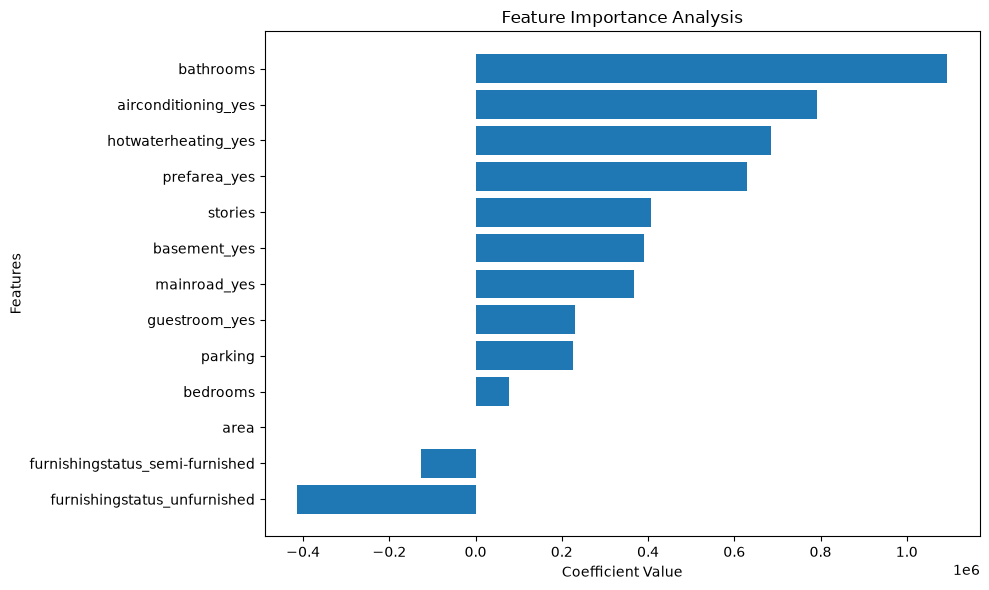

In [55]:
# Feature Importance Bar Chart

plt.figure(figsize=(10,6))

feature_importance_sorted = feature_importance.sort_values(
    by="Coefficient",
    ascending=True
)

plt.barh(
    feature_importance_sorted["Feature"],
    feature_importance_sorted["Coefficient"]
)

plt.xlabel("Coefficient Value")
plt.ylabel("Features")

plt.title("Feature Importance Analysis")

plt.tight_layout()

plt.savefig("charts/feature_importance.png", bbox_inches="tight")

plt.show()

### Observation

The feature importance chart clearly shows which property characteristics contribute most significantly to house price prediction.

Bathrooms, air conditioning, hot water heating, preferred area, and number of stories emerged as the strongest positive contributors to property valuation.

This visualization enhances the interpretability of the machine learning model by explaining the factors responsible for price predictions.

# 9. Explainable AI Insights

Unlike traditional prediction systems that only provide output values, Explainable AI focuses on understanding the factors responsible for those predictions.

### Key Findings

🔹 **Bathrooms emerged as the strongest positive contributor** to property valuation.

🔹 **Facilities such as air conditioning and hot water heating** significantly increased predicted house prices.

🔹 **Properties located in preferred areas** generally showed higher market value.

🔹 **Additional stories and parking facilities** positively influenced property prices.

🔹 **Unfurnished properties** had a negative impact on valuation compared to furnished properties.

### Why Explainable AI Matters

🔹 Helps buyers understand factors affecting property prices.

🔹 Supports sellers in identifying improvements that increase property value.

🔹 Enables real estate businesses to make transparent and data-driven pricing decisions.

🔹 Builds trust by explaining how machine learning predictions are generated.

### Final Insight

🔹 This project not only predicts house prices but also explains the factors influencing those predictions, making it an Explainable AI-based real estate valuation system.


# 10. Business Recommendations

### Recommended Actions

✅ Invest in property features such as air conditioning and hot water heating, as these amenities positively influence house prices.

✅ Focus on developments in preferred residential areas where property valuation tends to be higher.

✅ Improve furnishing quality and overall property presentation to increase market value.

✅ Utilize machine learning-based valuation systems to support faster, more consistent, and data-driven pricing decisions.

✅ Leverage feature importance insights to identify the property characteristics that generate the highest return on investment.

### Strategic Impact

✅ These recommendations can help real estate businesses improve pricing accuracy, enhance customer trust, and maximize property value.


# 11. Key Project Insights 

### Which Features Influence House Price the Most?

Bathrooms, air conditioning, hot water heating, preferred area, and number of stories were identified as the most influential factors affecting house prices.

### How Accurate Was the Model?

The Linear Regression model achieved an R² Score of approximately 65.3%, indicating that it successfully captured a significant portion of the variation in house prices.

### What Surprised Me in the Data?

One interesting observation was that facilities such as air conditioning and hot water heating had a stronger influence on house prices than expected. Furnishing status also showed a noticeable impact on property valuation.

### Recommendation for Real Estate Businesses

Real estate companies should focus on property features that significantly influence pricing decisions, such as modern amenities, preferred locations, and furnishing quality, while leveraging machine learning-based valuation systems for more consistent pricing.


# 12. Conclusion

◆ **Project Achievement**

This project successfully developed an Explainable AI-based House Price Prediction System using machine learning techniques and real-world housing data.

◆ **Data Analysis**

The housing dataset was explored, cleaned, transformed, and analyzed to identify the factors influencing property valuation. Exploratory Data Analysis (EDA) revealed meaningful relationships between property characteristics and house prices.

◆ **Model Performance**

Two machine learning models were trained and evaluated. Linear Regression achieved the best performance with an R² Score of approximately 65.3%, making it the most suitable model for this dataset.

◆ **Key Price Drivers**

Feature importance analysis identified bathrooms, air conditioning, hot water heating, preferred area, and number of stories as major contributors to house prices.

◆ **Explainable AI Impact**

The project not only predicts house prices but also explains the factors influencing those predictions, improving transparency and trust in machine learning-based valuation systems.

◆ **Business Value**

This solution demonstrates how Explainable AI and machine learning can transform traditional property valuation into a more transparent, accurate, and data-driven process, enabling buyers, sellers, and real estate businesses to make informed pricing decisions with greater confidence.
